<a href="https://colab.research.google.com/github/Yash-k10/Machine_vision/blob/main/practical8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 2.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Upload an image containing packages/objects:


Saving images1.jpeg to images1.jpeg
Image uploaded successfully!


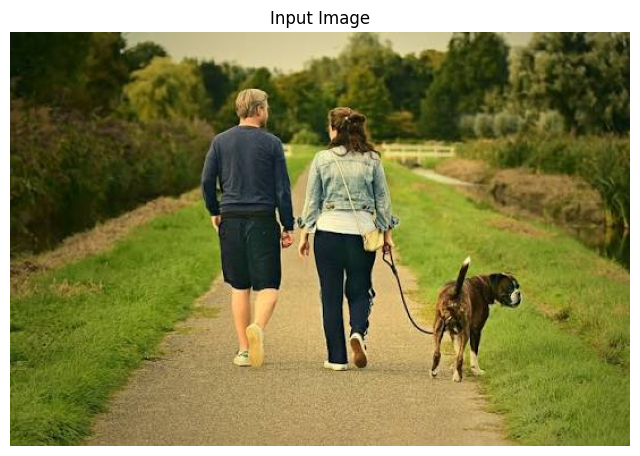

Loading YOLO model...
YOLO model loaded successfully!


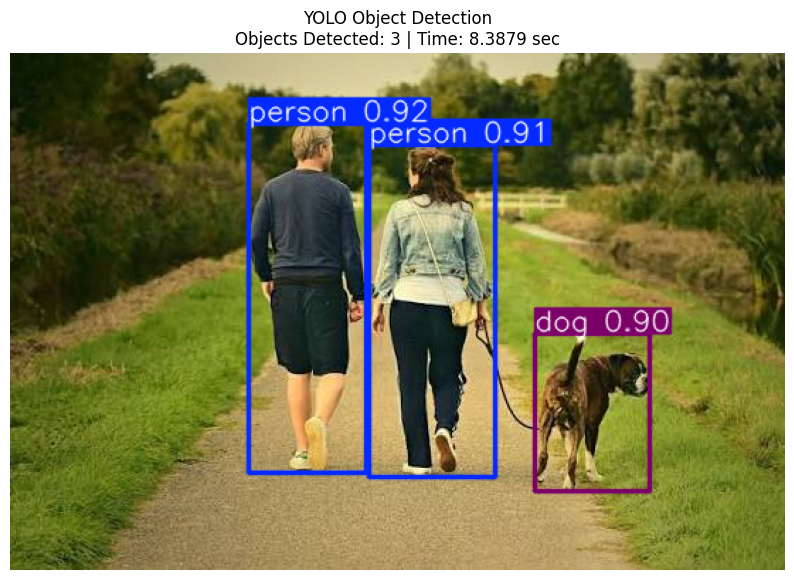


========== YOLO DETECTION DETAILS ==========
Object: person          Confidence: 0.92 Location: (168, 50) -> (251, 296)
Object: person          Confidence: 0.91 Location: (253, 65) -> (342, 299)
Object: dog             Confidence: 0.90 Location: (370, 198) -> (451, 309)


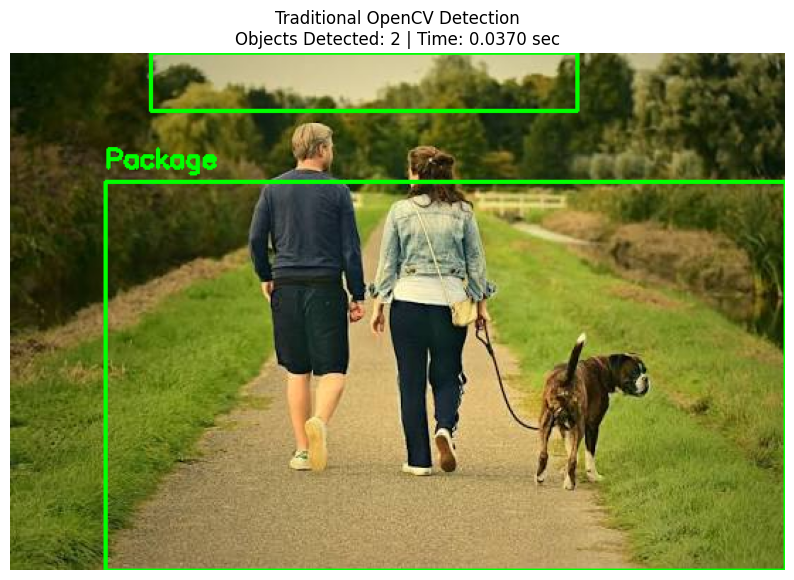

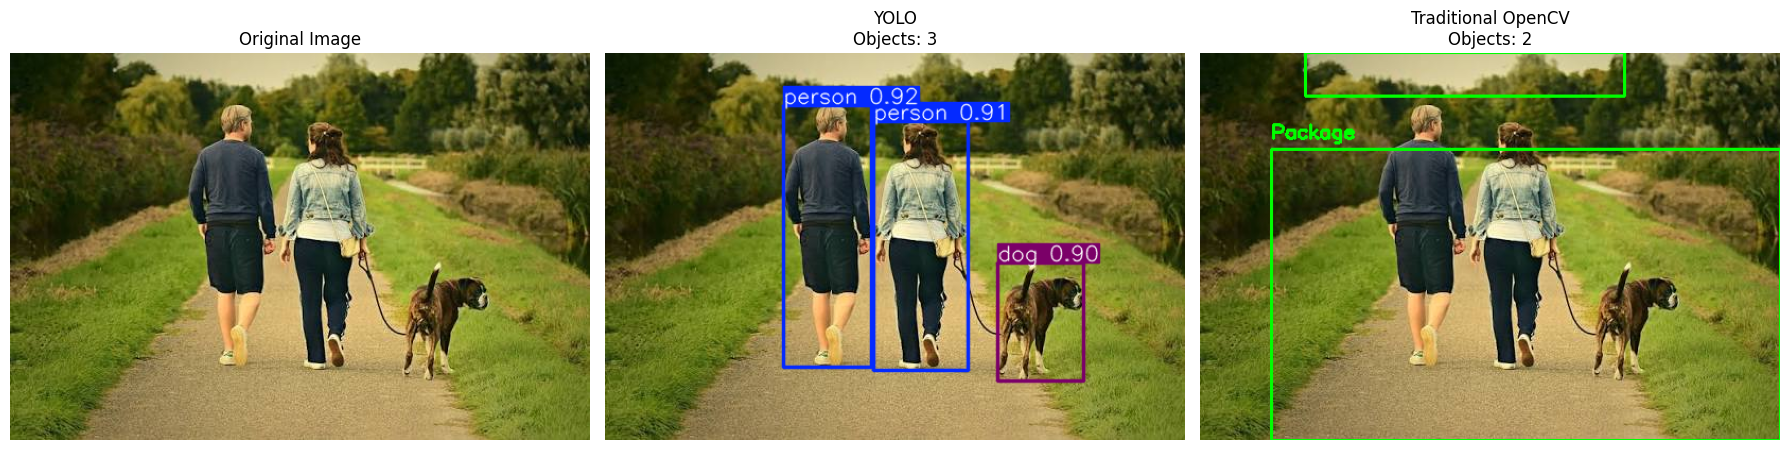


========== PERFORMANCE COMPARISON ==========



,Method,Objects Detected,Detection Time (sec),FPS
0,YOLO,3,8.3879,0.12
1,Traditional OpenCV,2,0.0370,27.01


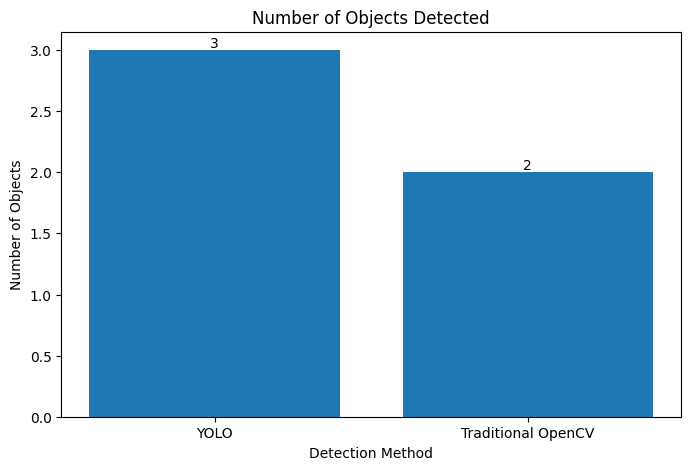

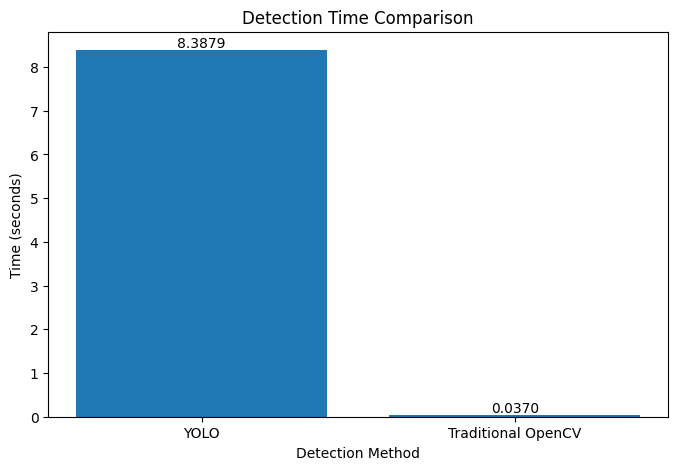

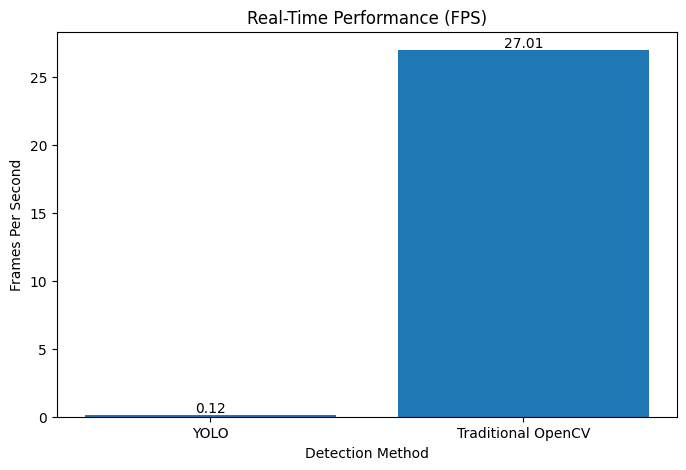


              FINAL RESULT

YOLO:
Objects Detected : 3
Detection Time   : 8.3879 seconds
FPS              : 0.12

Traditional OpenCV:
Objects Detected : 2
Detection Time   : 0.0370 seconds
FPS              : 27.01

CONCLUSION

YOLO provides more robust object detection because
it can recognize different types of objects and
provide bounding boxes and confidence scores.

Traditional OpenCV contour detection mainly depends
on object shape, edges, thresholding and lighting.

Therefore, YOLO is more suitable for real-world
logistics applications where packages can appear
at different positions, sizes and backgrounds.



In [1]:
# ============================================================
# OBJECT DETECTION USING YOLO + OPENCV DNN / TRADITIONAL METHOD
# Logistics Package Detection Practical
# ============================================================

# STEP 1: INSTALL LIBRARIES
!pip install ultralytics opencv-python matplotlib pandas -q


# STEP 2: IMPORT LIBRARIES
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO
from google.colab import files


# ============================================================
# STEP 3: UPLOAD IMAGE
# ============================================================

print("Upload an image containing packages/objects:")

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)

if image is None:
    print("Error: Could not read image.")
else:
    print("Image uploaded successfully!")

# Convert BGR -> RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# ============================================================
# STEP 4: DISPLAY INPUT IMAGE
# ============================================================

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Input Image")
plt.axis("off")
plt.show()


# ============================================================
# STEP 5: LOAD YOLO MODEL
# ============================================================

print("Loading YOLO model...")

model = YOLO("yolo11n.pt")

print("YOLO model loaded successfully!")


# ============================================================
# STEP 6: YOLO OBJECT DETECTION
# ============================================================

start_time = time.time()

results = model(image, verbose=False)

yolo_time = time.time() - start_time

result = results[0]

# Number of detected objects
yolo_count = len(result.boxes)

# Annotated image
yolo_image = result.plot()

# Convert BGR -> RGB
yolo_rgb = cv2.cvtColor(yolo_image, cv2.COLOR_BGR2RGB)


# ============================================================
# STEP 7: DISPLAY YOLO RESULT
# ============================================================

plt.figure(figsize=(10, 7))

plt.imshow(yolo_rgb)

plt.title(
    f"YOLO Object Detection\n"
    f"Objects Detected: {yolo_count} | "
    f"Time: {yolo_time:.4f} sec"
)

plt.axis("off")

plt.show()


# ============================================================
# STEP 8: DISPLAY YOLO DETECTION DETAILS
# ============================================================

print("\n========== YOLO DETECTION DETAILS ==========")

for box in result.boxes:

    class_id = int(box.cls[0])

    confidence = float(box.conf[0])

    class_name = model.names[class_id]

    x1, y1, x2, y2 = box.xyxy[0].tolist()

    print(
        f"Object: {class_name:15s} "
        f"Confidence: {confidence:.2f} "
        f"Location: ({int(x1)}, {int(y1)}) -> "
        f"({int(x2)}, {int(y2)})"
    )


# ============================================================
# STEP 9: TRADITIONAL OPENCV DETECTION
# ============================================================

def traditional_detection(image):

    start_time = time.time()

    img = image.copy()

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Reduce noise
    blur = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )

    # Thresholding
    _, thresh = cv2.threshold(
        blur,
        120,
        255,
        cv2.THRESH_BINARY
    )

    # Find contours
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    detected_objects = 0

    for contour in contours:

        area = cv2.contourArea(contour)

        # Ignore very small regions
        if area < 1000:
            continue

        perimeter = cv2.arcLength(
            contour,
            True
        )

        approx = cv2.approxPolyDP(
            contour,
            0.02 * perimeter,
            True
        )

        # Check for approximately rectangular shape
        if len(approx) >= 4:

            x, y, w, h = cv2.boundingRect(
                contour
            )

            if w > 30 and h > 30:

                cv2.rectangle(
                    img,
                    (x, y),
                    (x + w, y + h),
                    (0, 255, 0),
                    2
                )

                cv2.putText(
                    img,
                    "Package",
                    (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2
                )

                detected_objects += 1

    detection_time = time.time() - start_time

    return img, detected_objects, detection_time


# Run traditional detection

traditional_image, traditional_count, traditional_time = \
    traditional_detection(image)

traditional_rgb = cv2.cvtColor(
    traditional_image,
    cv2.COLOR_BGR2RGB
)


# ============================================================
# STEP 10: DISPLAY TRADITIONAL RESULT
# ============================================================

plt.figure(figsize=(10, 7))

plt.imshow(traditional_rgb)

plt.title(
    f"Traditional OpenCV Detection\n"
    f"Objects Detected: {traditional_count} | "
    f"Time: {traditional_time:.4f} sec"
)

plt.axis("off")

plt.show()


# ============================================================
# STEP 11: SIDE-BY-SIDE VISUAL COMPARISON
# ============================================================

plt.figure(figsize=(18, 6))


# Original
plt.subplot(1, 3, 1)

plt.imshow(image_rgb)

plt.title("Original Image")

plt.axis("off")


# YOLO
plt.subplot(1, 3, 2)

plt.imshow(yolo_rgb)

plt.title(
    f"YOLO\n"
    f"Objects: {yolo_count}"
)

plt.axis("off")


# Traditional
plt.subplot(1, 3, 3)

plt.imshow(traditional_rgb)

plt.title(
    f"Traditional OpenCV\n"
    f"Objects: {traditional_count}"
)

plt.axis("off")


plt.tight_layout()

plt.show()


# ============================================================
# STEP 12: CALCULATE FPS
# ============================================================

yolo_fps = 1 / yolo_time

traditional_fps = 1 / traditional_time


# ============================================================
# STEP 13: PERFORMANCE COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({

    "Method": [
        "YOLO",
        "Traditional OpenCV"
    ],

    "Objects Detected": [
        yolo_count,
        traditional_count
    ],

    "Detection Time (sec)": [
        round(yolo_time, 4),
        round(traditional_time, 4)
    ],

    "FPS": [
        round(yolo_fps, 2),
        round(traditional_fps, 2)
    ]
})


print("\n========== PERFORMANCE COMPARISON ==========\n")

display(comparison)


# ============================================================
# STEP 14: VISUALIZE DETECTION COUNT
# ============================================================

methods = [
    "YOLO",
    "Traditional OpenCV"
]

counts = [
    yolo_count,
    traditional_count
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    methods,
    counts
)

plt.title("Number of Objects Detected")

plt.xlabel("Detection Method")

plt.ylabel("Number of Objects")

# Add values above bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha="center",
        va="bottom"
    )

plt.show()


# ============================================================
# STEP 15: VISUALIZE DETECTION TIME
# ============================================================

times = [
    yolo_time,
    traditional_time
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    methods,
    times
)

plt.title("Detection Time Comparison")

plt.xlabel("Detection Method")

plt.ylabel("Time (seconds)")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom"
    )

plt.show()


# ============================================================
# STEP 16: VISUALIZE FPS
# ============================================================

fps_values = [
    yolo_fps,
    traditional_fps
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    methods,
    fps_values
)

plt.title("Real-Time Performance (FPS)")

plt.xlabel("Detection Method")

plt.ylabel("Frames Per Second")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.show()


# ============================================================
# STEP 17: FINAL RESULT
# ============================================================

print("\n==============================================")
print("              FINAL RESULT")
print("==============================================")

print(f"\nYOLO:")
print(f"Objects Detected : {yolo_count}")
print(f"Detection Time   : {yolo_time:.4f} seconds")
print(f"FPS              : {yolo_fps:.2f}")

print("\nTraditional OpenCV:")
print(f"Objects Detected : {traditional_count}")
print(f"Detection Time   : {traditional_time:.4f} seconds")
print(f"FPS              : {traditional_fps:.2f}")


print("\n==============================================")
print("CONCLUSION")
print("==============================================")

print("""
YOLO provides more robust object detection because
it can recognize different types of objects and
provide bounding boxes and confidence scores.

Traditional OpenCV contour detection mainly depends
on object shape, edges, thresholding and lighting.

Therefore, YOLO is more suitable for real-world
logistics applications where packages can appear
at different positions, sizes and backgrounds.
""")